# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

---

### Dataset yang Digunakan: **Iris Dataset**

- **Sumber**: UCI Machine Learning Repository / `sklearn.datasets.load_iris`.
- **Jumlah baris / kolom**: 150 baris × 5 kolom (4 fitur numerik + 1 target).
- **Deskripsi fitur**:
    - `sepal_length` (cm) — panjang sepal bunga.
    - `sepal_width`  (cm) — lebar sepal bunga.
    - `petal_length` (cm) — panjang petal bunga.
    - `petal_width`  (cm) — lebar petal bunga.
- **Target / Label**: `species` dengan 3 kelas — *setosa*, *versicolor*, *virginica*.
- **Tugas**: klasifikasi multi-kelas (3 kelas, balanced 50/50/50).
- **Alasan memilih dataset ini**: ukurannya kecil, bersih, balanced, sehingga cocok untuk demo end-to-end pipeline preprocessing → modelling → CI → monitoring tanpa terkendala compute.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('Semua library berhasil di-import.')


Semua library berhasil di-import.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan.

In [2]:
# Load dataset Iris dari folder iris_raw
df = pd.read_csv('../iris_raw/iris.csv')

print('Shape dataset :', df.shape)
print('Kolom         :', list(df.columns))
df.head()


Shape dataset : (150, 5)
Kolom         : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Informasi tipe data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# Statistik deskriptif
df.describe(include='all')


,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### 4.1 Cek Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values ===')
print(missing_df)
print(f"\nTotal missing: {df.isnull().sum().sum()}")


=== Missing Values ===
              Missing Count  Missing %
sepal_length              0        0.0
sepal_width               0        0.0
petal_length              0        0.0
petal_width               0        0.0
species                   0        0.0

Total missing: 0


### 4.2 Cek Data Duplikat

In [6]:
print('=== Data Duplikat ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')


=== Data Duplikat ===
Jumlah baris duplikat: 1


### 4.3 Distribusi Target

=== Distribusi Target ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


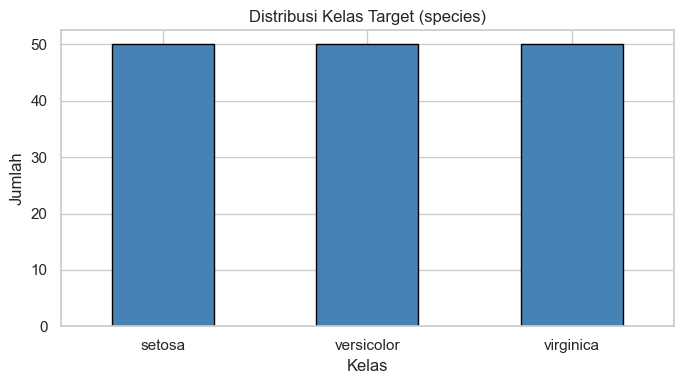

In [7]:
target_col = 'species'

print('=== Distribusi Target ===')
print(df[target_col].value_counts())

plt.figure(figsize=(7, 4))
df[target_col].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Kelas Target (species)')
plt.xlabel('Kelas'); plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 4.4 Distribusi Fitur Numerik

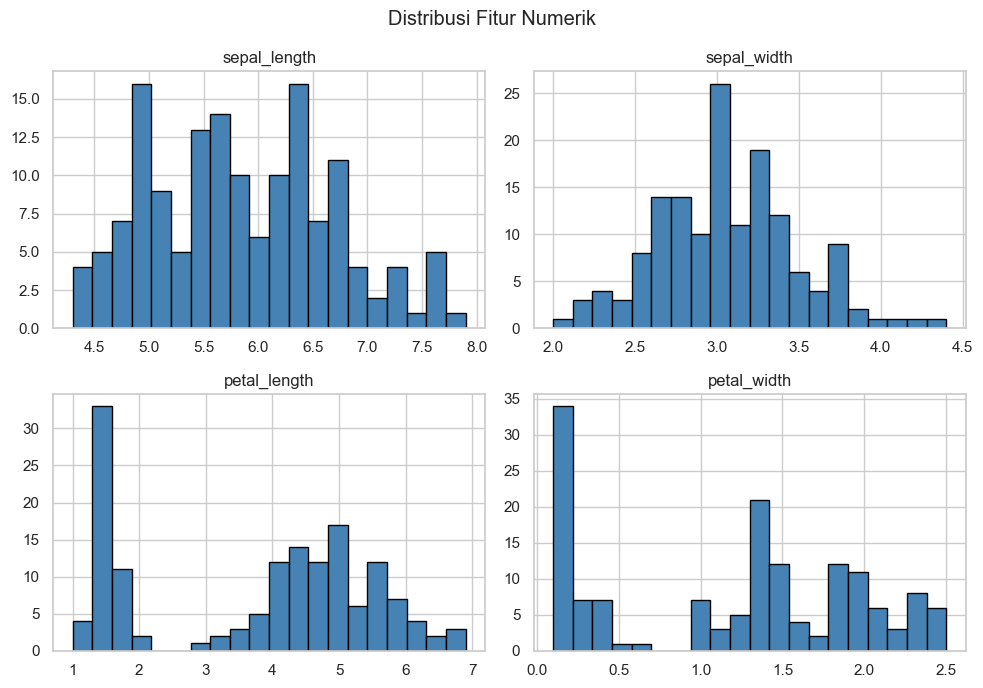

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].hist(figsize=(10, 7), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout()
plt.show()


### 4.5 Heatmap Korelasi

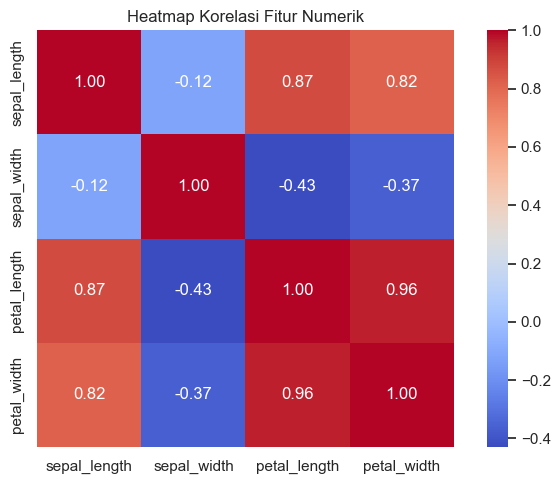

In [9]:
plt.figure(figsize=(7, 5))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()


### 4.6 Boxplot Outlier

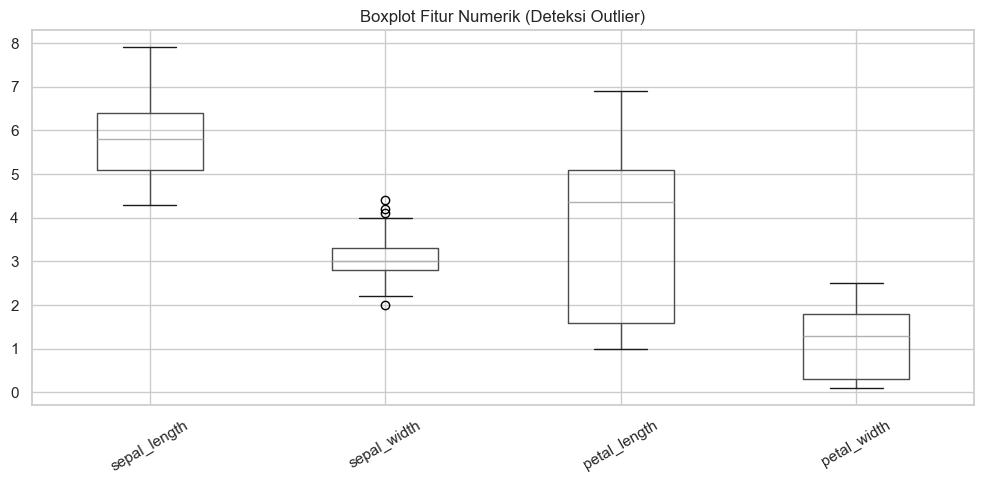

In [10]:
plt.figure(figsize=(10, 5))
df[num_cols].boxplot()
plt.title('Boxplot Fitur Numerik (Deteksi Outlier)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 4.7 Pairplot Antar Fitur (warnai berdasarkan target)

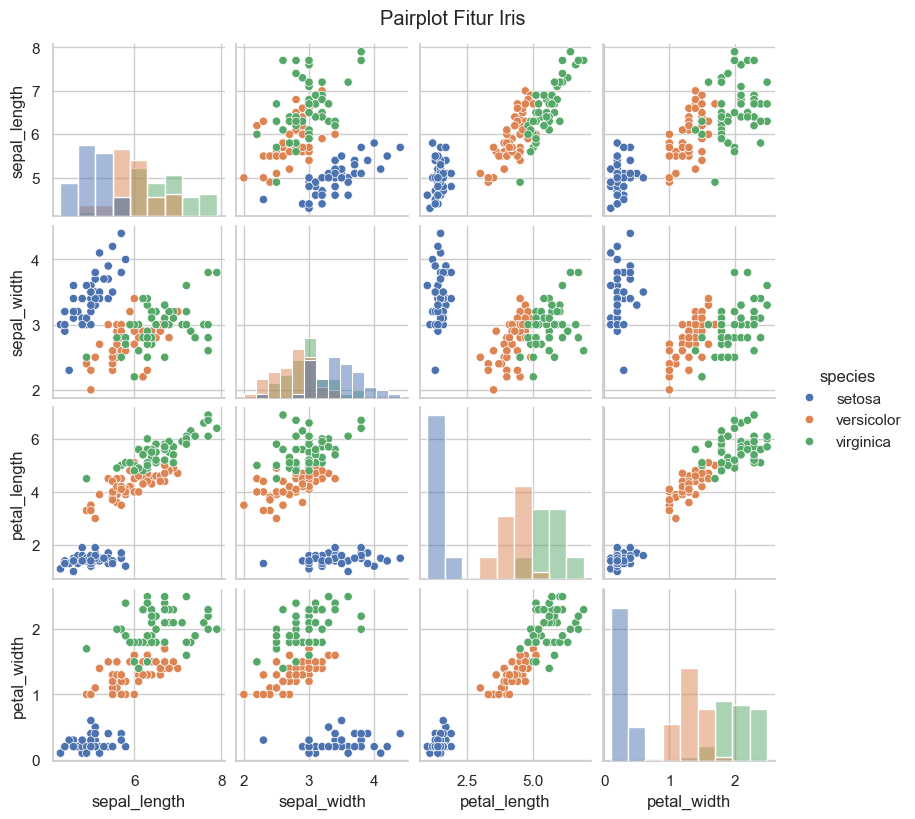

In [11]:
sns.pairplot(df, hue=target_col, diag_kind='hist', height=2.0)
plt.suptitle('Pairplot Fitur Iris', y=1.02)
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

### 5.1 Handle Missing Values

In [12]:
num_cols_feat = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
cat_cols      = [c for c in df.select_dtypes(include=['object']).columns if c != target_col]

if num_cols_feat:
    num_imputer = SimpleImputer(strategy='median')
    df[num_cols_feat] = num_imputer.fit_transform(df[num_cols_feat])

if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print(f'Missing values setelah handling: {df.isnull().sum().sum()}')


Missing values setelah handling: 0


### 5.2 Handle Duplikat

In [13]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after  = len(df)
print(f'Baris dihapus: {before - after} | Total sekarang: {after}')


Baris dihapus: 1 | Total sekarang: 149


### 5.3 Encoding Fitur Kategorikal & Target

In [14]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'  Encoded fitur kategorikal: {col}')

if df[target_col].dtype == 'object':
    target_le = LabelEncoder()
    df[target_col] = target_le.fit_transform(df[target_col])
    print(f'  Encoded target: {target_col} -> {dict(zip(target_le.classes_, range(len(target_le.classes_))))}')


  Encoded target: species -> {'setosa': 0, 'versicolor': 1, 'virginica': 2}


### 5.4 Train-Test Split

In [15]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')


X_train: (119, 4) | X_test: (30, 4)
y_train: (119,) | y_test: (30,)


### 5.5 Feature Scaling (StandardScaler)

In [16]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)
print('Scaling selesai.')
X_train_scaled.head()


Scaling selesai.


,sepal_length,sepal_width,petal_length,petal_width
0,-1.501587,0.769031,-1.339093,-1.179737
1,0.639824,-0.586742,1.041834,1.186365
2,-0.192947,-0.134818,0.248192,0.003314
3,-0.906751,1.672881,-1.055649,-1.048287
4,-1.263653,0.091144,-1.225715,-1.311187


### 5.6 Simpan Hasil Preprocessing

In [17]:
output_dir = 'iris_preprocessing'
os.makedirs(output_dir, exist_ok=True)

X_train_scaled.to_csv(f'{output_dir}/X_train.csv', index=False)
X_test_scaled.to_csv(f'{output_dir}/X_test.csv',   index=False)
y_train.reset_index(drop=True).to_csv(f'{output_dir}/y_train.csv', index=False)
y_test.reset_index(drop=True).to_csv(f'{output_dir}/y_test.csv',   index=False)

print(f"Preprocessing selesai! File disimpan di '{output_dir}/'")
print(f'  X_train : {X_train_scaled.shape}')
print(f'  X_test  : {X_test_scaled.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')


Preprocessing selesai! File disimpan di 'iris_preprocessing/'
  X_train : (119, 4)
  X_test  : (30, 4)
  y_train : (119,)
  y_test  : (30,)
